# BuoyData.NDBC demonstration
This example walks through ingesting, processing, and visualizing spectral data from NDBC buoys. Begin by importing the necessary julia packages.

In [1]:
import Dates
import Unitful
import HDF5
using AxisArrays
using Plots

push!(LOAD_PATH, "../src")
import BuoyData: NDBC

## Identify available data
All available NDBC data can be evaluated with the `NDBC.available()` function, which optionally takes a buoy number argument.

In [2]:
avail = NDBC.available()


Row,buoy,year,b_file
,String,Int64,Bool
1,32012,2007,false
2,32012,2008,false
3,32012,2009,false
4,32012,2010,false
5,32012,2011,false
6,32012,2012,false
7,32012,2013,false
8,32012,2014,false
9,32012,2015,false


In [3]:
buoys = unique(avail[!, :buoy])

127-element Vector{String}:
 "32012"
 "41001"
 "41002"
 "41004"
 "41008"
 "41009"
 "41010"
 "41012"
 "41013"
 "41025"
 "41035"
 "41036"
 "41040"
 ⋮
 "46105"
 "46106"
 "46107"
 "48011"
 "51000"
 "51001"
 "51002"
 "51003"
 "51004"
 "51028"
 "51100"
 "51101"

The `available` function also takes arguments for the type of spectra of interest (directional or omnidirectional) and a variable number of keyword arguments that are passed to HTTP.jl calls. 

In [4]:
available_swden = NDBC.available(:omnidirectional_spectrum)
available_pacwave = NDBC.available(46050, :omnidirectional_spectrum; retries = 1)

Row,year,b_file
,Int64,Bool
1,1996,false
2,1997,false
3,1998,false
4,1999,false
5,2000,false
6,2001,false
7,2002,false
8,2003,false
9,2004,false


## Metadata for a given buoy
For the purpose of this example, we are interested in NDBC buoy 46050 near the PacWave site. 

In [5]:
buoy = 46050
metadata = NDBC.metadata(buoy)

Dict{String, Union{Nothing, Unitful.Quantity}} with 4 entries:
  "Longitude"           => -124.535°
  "Watch circle radius" => 211.226 m
  "Water depth"         => 149.0 m
  "Latitude"            => 44.679°

## Requesting data
The primary BuoyData.NDBC function is `request` which takes in a buoy number, year, 'bfile' flag, spectrum type, and data source. It ingests all data for that year (typically hourly) and returns WaveSpectra.jl Spectra or OmnidirectionalSpectra structures for the available buoy data.

The 'bfile' flag is used when data for that year was interrupted and recombined in some way. Whether a given data needs this flag can be determined using the results of the `available` function. 

In [6]:
year = 2021
bfile = available_pacwave[available_pacwave.year .== 2021, :].b_file == 1
data_historical = NDBC.request(buoy, year, bfile)
data_thredds = NDBC.request(buoy, year, bfile, :omnidirectional_spectrum, :thredds)

1-dimensional AxisArray{WaveSpectra.OmnidirectionalSpectrum,1,...} with axes:
    :time, Axis{:time, Vector{Dates.DateTime}}([Dates.DateTime("2021-01-01T00:00:00"), Dates.DateTime("2021-01-01T01:00:00"), Dates.DateTime("2021-01-01T02:00:00"), Dates.DateTime("2021-01-01T03:00:00"), Dates.DateTime("2021-01-01T04:00:00"), Dates.DateTime("2021-01-01T05:00:00"), Dates.DateTime("2021-01-01T06:00:00"), Dates.DateTime("2021-01-01T07:00:00"), Dates.DateTime("2021-01-01T08:00:00"), Dates.DateTime("2021-01-01T09:00:00")  …  Dates.DateTime("2021-12-31T14:00:00"), Dates.DateTime("2021-12-31T15:00:00"), Dates.DateTime("2021-12-31T16:00:00"), Dates.DateTime("2021-12-31T17:00:00"), Dates.DateTime("2021-12-31T18:00:00"), Dates.DateTime("2021-12-31T19:00:00"), Dates.DateTime("2021-12-31T20:00:00"), Dates.DateTime("2021-12-31T21:00:00"), Dates.DateTime("2021-12-31T22:00:00"), Dates.DateTime("2021-12-31T23:00:00")])
And data, a 8589-element Vector{WaveSpectra.OmnidirectionalSpectrum}:
 47×1-Omnidirectiona

## Data caching
All data (spectra from both the historical and thredds databases, metadata, and description of available data) is cached upon first use and stored in "~/.cache/JuliaOceanWaves/BuoyData/NDBC". BuoyData.NDBC functions will always first look for and read this data locally if available. Data is always stored upon first download. This prevents the server from being overloaded with repeated calls and testing, and reduces computational and network expenses for the user.

Specific local datafiles can be read with `read` and `read_netcdf` and their raw data is returned without being converted to WaveSpectra types.

In [7]:
d1 = NDBC.read(joinpath("data", "41001i2015.txt.gz"))
d2 = NDBC.read(joinpath("data", "41001i2015.txt"))
d3 = NDBC.read(joinpath("data", "41001i2015.txt.gz"), "swdir2")
d4 = NDBC.read_netcdf(joinpath(homedir(), ".cache", "JuliaOceanWaves", "BuoyData", "NDBC", "thredds", "46050w2021.nc"), "swden") # this data is available if the above cells are run


2-dimensional AxisArray{Unitful.Quantity{Float32, 𝐋^2 𝐓, Unitful.FreeUnits{(Hz^-1, m^2), 𝐋^2 𝐓, nothing}},2,...} with axes:
    :time, [Dates.DateTime("2021-01-01T00:00:00"), Dates.DateTime("2021-01-01T01:00:00"), Dates.DateTime("2021-01-01T02:00:00"), Dates.DateTime("2021-01-01T03:00:00"), Dates.DateTime("2021-01-01T04:00:00"), Dates.DateTime("2021-01-01T05:00:00"), Dates.DateTime("2021-01-01T06:00:00"), Dates.DateTime("2021-01-01T07:00:00"), Dates.DateTime("2021-01-01T08:00:00"), Dates.DateTime("2021-01-01T09:00:00")  …  Dates.DateTime("2021-12-31T14:00:00"), Dates.DateTime("2021-12-31T15:00:00"), Dates.DateTime("2021-12-31T16:00:00"), Dates.DateTime("2021-12-31T17:00:00"), Dates.DateTime("2021-12-31T18:00:00"), Dates.DateTime("2021-12-31T19:00:00"), Dates.DateTime("2021-12-31T20:00:00"), Dates.DateTime("2021-12-31T21:00:00"), Dates.DateTime("2021-12-31T22:00:00"), Dates.DateTime("2021-12-31T23:00:00")]
    :frequency, Unitful.Quantity{Float32, 𝐓^-1, Unitful.FreeUnits{(Hz,), 𝐓^-1, no

## Visualization and manipulation
See WaveSpectra.jl for manipulating and using spectra data.

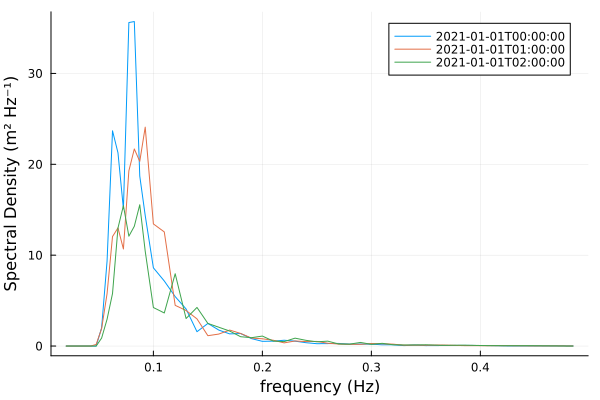

In [8]:
Plots.plot(data_thredds[1], label=data_thredds.axes[1][1])
Plots.plot!(data_thredds[2], label=data_thredds.axes[1][2])
Plots.plot!(data_thredds[3], label=data_thredds.axes[1][3])